# using less

In [85]:
from collections import defaultdict
import json
import math

# Load data
with open('finalstep_stats_3.json') as f:
    data = json.load(f)
with open('finalrandla_stats_3.json') as f2:
    data2 = json.load(f2)
with open('finalmean_stats_3.json') as f3:
    data3 = json.load(f3)
with open('finalrandom_2.json') as f4:
    data4 = json.load(f4)
with open('finalrandom_1.json') as f5:
    data5 = json.load(f5)
with open('finalcombine_stats_3.json') as f6:
    data6 = json.load(f6)


def euclidean(p1, p2):
    """Simple 2D Euclidean distance"""
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)


# -------------------------------------------------
# Environment mapping + snapping
# -------------------------------------------------
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "mutlti ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}


def get_env_name(start_point, goal_point, max_snap_dist=5.0):
    """
    Map (start, goal) to the closest known environment in env_map.
    """
    # 1) Exact rounded lookup (backwards compatible)
    start_rounded = tuple(round(x) for x in start_point)
    goal_rounded = tuple(round(x) for x in goal_point)
    key = (start_rounded, goal_rounded)

    if key in env_map:
        return env_map[key]

    # 2) Find closest template pair in env_map
    best_name = None
    best_dist = float("inf")

    for (tmpl_start, tmpl_goal), name in env_map.items():
        dist = euclidean(start_point, tmpl_start) + euclidean(goal_point, tmpl_goal)
        if dist < best_dist:
            best_dist = dist
            best_name = name

    # 3) Snap if close enough
    if best_dist <= max_snap_dist:
        return best_name

    # Fallback: keep explicit mapping
    return f"{start_rounded}→{goal_rounded}"


# -------------------------------------------------
# Processing (now grouped by environment name)
# -------------------------------------------------
def process_data(data):
    groups = defaultdict(list)

    for entry in data:
        env_key = get_env_name(entry["start_point"], entry["goal_point"])
        groups[env_key].append(entry)

    stats = {}
    for key, group in groups.items():
        total_lengths = [sum(entry["total_length"]) for entry in group]
        dist_togoals = [entry["dist_to_goal"] for entry in group]
        collision_counts = [entry["collision_count"] for entry in group]
        counts = [entry["count"] for entry in group]
        reach_goals = [entry["reach_goal"] for entry in group]

        # Distances involving current_pos
        dist_start_curr = [
            euclidean(entry["start_point"], entry["current_pos"]) for entry in group
        ]
        dist_curr_goal = [
            euclidean(entry["current_pos"], entry["goal_point"]) for entry in group
        ]

        mean_total_length = sum(total_lengths) / len(total_lengths)
        mean_dist_togoal = sum(dist_togoals) / len(dist_togoals)
        mean_collision = sum(collision_counts) / len(collision_counts)
        mean_count = sum(counts) / len(counts)
        reach_goal_rate = sum(reach_goals) / len(reach_goals)

        mean_start_curr = sum(dist_start_curr) / len(dist_start_curr)
        mean_curr_goal = sum(dist_curr_goal) / len(dist_curr_goal)

        success_collision_counts = [
            entry["collision_count"] for entry in group if entry.get("reach_goal")
        ]
        mean_collision_success = (
            sum(success_collision_counts) / len(success_collision_counts)
            if success_collision_counts else 0.0
        )

        # ---------------------------------------------
        # Flip-over metric:
        #   reach_goal == False AND count != 700
        # ---------------------------------------------
        flip_over_flags = [
            (not entry["reach_goal"]) and (entry["count"] != 700)
            for entry in group
        ]
        flip_over_count = sum(flip_over_flags)          # e.g. 3 (out of 20)
        flip_over_rate = flip_over_count / len(group) * 100.0  # percent, like (3/20)*100

        stats[key] = {
            "total_length": mean_total_length,
            "dist_togoal": mean_dist_togoal,
            "collision_count": mean_collision,
            "count": mean_count,
            "reach_goal_rate": reach_goal_rate * 100,  # percent
            "dist_start_to_current": mean_start_curr,
            "dist_current_to_goal": mean_curr_goal,
            "mean_collision_success": mean_collision_success,
            "flip_over_count": flip_over_count,        # how many flips out of N (e.g. 3 of 20)
            "flip_over_rate": flip_over_rate,          # as percentage
        }
    return stats


# Process all datasets (stats now keyed by env name like 'hole', 'normal', etc.)
stats1 = process_data(data)
stats2 = process_data(data2)
stats3 = process_data(data3)
stats4 = process_data(data4)
stats5 = process_data(data5)
stats6 = process_data(data6)


In [86]:
# import matplotlib.pyplot as plt
# import numpy as np
# from collections import defaultdict

# # Environment mapping (same as before)
# env_map = {
#     ((-30, 7), (-22, 17)): "normal",
#     ((-30, -20), (-22, -6)): "uneven",
#     ((-31, -44), (-20, -37)): "mutlti ramp",
#     ((-55, 5), (-41, 5)): "two_height_ramp",
#     ((-33, 40), (-20, 40)): "ramp_obstacle",
#     ((-55, -13), (-41, -13)): "hole",
# }

# def get_env_name(start_point, goal_point):
#     """Round points and look up in env_map, fallback to 'start→goal' string."""
#     start = tuple(round(x) for x in start_point)
#     goal = tuple(round(x) for x in goal_point)
#     return env_map.get((start, goal), f"{start}→{goal}")

# # count how many successful runs per map for RandLA (data2)
# map_counts = defaultdict(int)

# for entry in data:
#     # if entry.get('reach_goal'):  # only successful runs; remove this if you want all runs
#     map_name = get_env_name(entry["start_point"], entry["goal_point"])
#     map_counts[map_name] += 1

# # print map counts
# print(dict(map_counts))


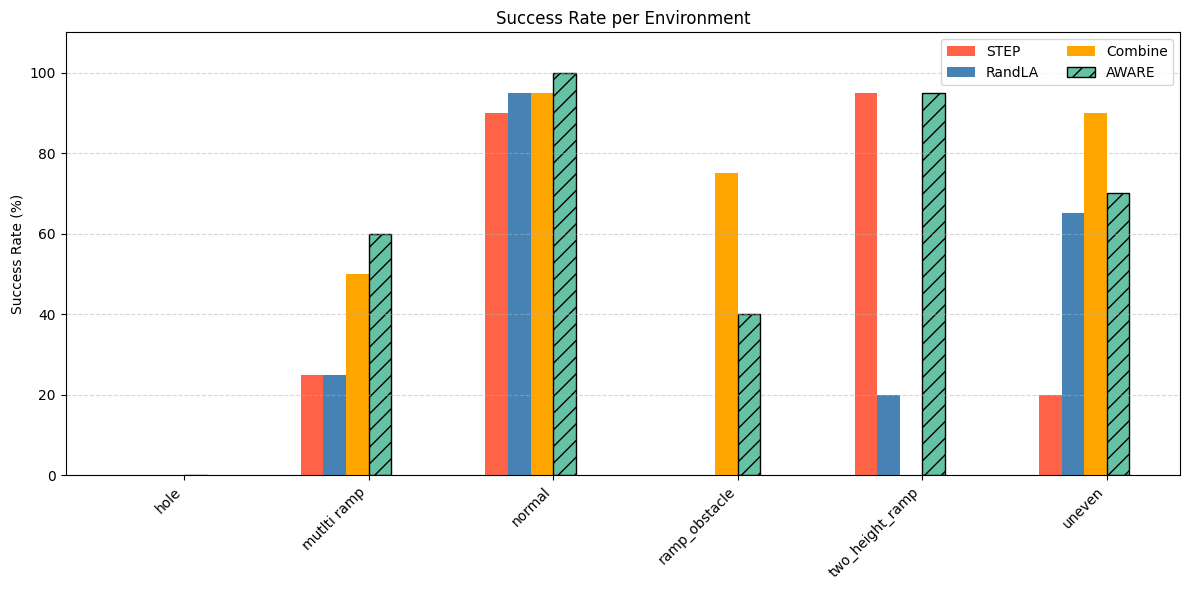

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# Environment mapping (same as before)
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "mutlti ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

# Convert stats1/stats2... keys from coordinates to labels
def relabel_stats(stats):
    new_stats = {}
    for key, values in stats.items():
        # If key is already a string like "hole", keep it
        if isinstance(key, str):
            label = key
        # If key is a (start, goal) tuple, map it through env_map
        elif isinstance(key, tuple) and len(key) == 2:
            start, goal = key
            label = env_map.get((start, goal), f"{start}→{goal}")
        else:
            label = str(key)
        new_stats[label] = values
    return new_stats


stats1_labeled = relabel_stats(stats1)
stats2_labeled = relabel_stats(stats2)
stats3_labeled = relabel_stats(stats3)
stats4_labeled = relabel_stats(stats4)
stats5_labeled = relabel_stats(stats5)
stats6_labeled = relabel_stats(stats6)  # <-- NEW

# Combine all labels (now includes stats5 and stats6)
all_labels = sorted(
    set(stats1_labeled.keys())
    .union(stats2_labeled.keys())
    .union(stats3_labeled.keys())
    .union(stats4_labeled.keys())
    .union(stats5_labeled.keys())
    .union(stats6_labeled.keys())
)

# Build series
step_rates    = [stats1_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
randla_rates  = [stats2_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
combine_rates = [stats3_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
full_rates    = [stats4_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
test_rates    = [stats5_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
new_rates     = [stats6_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]  # <-- NEW

# Plotting
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing

width = 0.22  # slightly narrower to fit 6 bars per group
offsets = [-2.5*width, -1.5*width, -0.5*width, 0.5*width, 1.5*width, 2.5*width]  # <-- 6 slots

plt.figure(figsize=(max(12, len(all_labels)*0.8), 6))

plt.bar(x + offsets[0], step_rates,    width, label='STEP', color='tomato')
plt.bar(x + offsets[1], randla_rates,  width, label='RandLA', color='steelblue')
plt.bar(x + offsets[2], combine_rates, width, label='Combine', color='orange')
# plt.bar(x + offsets[3], full_rates,    width, label='Full map Combine ', color='purple',edgecolor='black',hatch='//' )
# plt.bar(x + offsets[4], test_rates,    width, label='Partial full map Combine', color='orange',edgecolor='black',hatch='//' )
plt.bar(
    x + offsets[3],
    new_rates,
    width,
    label='AWARE',
    color='#66C2A5',
    edgecolor='black',hatch='//'  
)

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Success Rate (%)")
plt.ylim(0, 110)
plt.title("Success Rate per Environment")
plt.legend(ncol=2)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


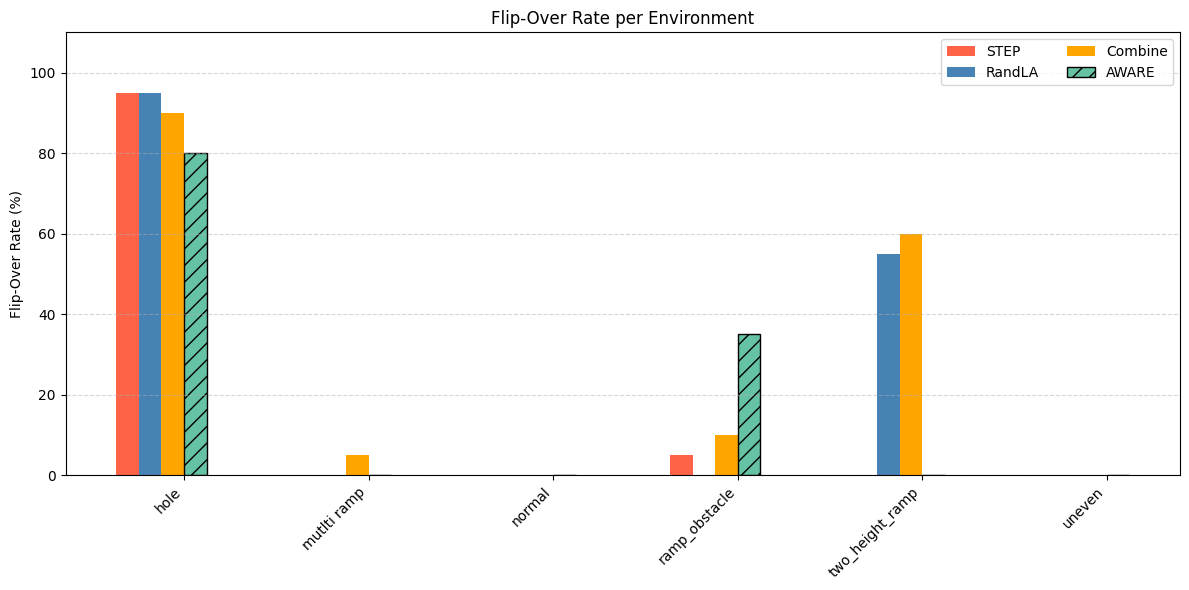

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# Build flip-over series
step_flip    = [stats1_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]
randla_flip  = [stats2_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]
combine_flip = [stats3_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]
full_flip    = [stats4_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]
test_flip    = [stats5_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]
new_flip     = [stats6_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]

# Plotting
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing

width = 0.22
offsets = [-2.5*width, -1.5*width, -0.5*width, 0.5*width, 1.5*width, 2.5*width]

plt.figure(figsize=(max(12, len(all_labels)*0.8), 6))

plt.bar(x + offsets[0], step_flip,    width, label='STEP', color='tomato')
plt.bar(x + offsets[1], randla_flip,  width, label='RandLA', color='steelblue')
plt.bar(x + offsets[2], combine_flip, width, label='Combine', color='orange')

plt.bar(
    x + offsets[3],
    new_flip,
    width,
    label='AWARE',
    color='#66C2A5',
    edgecolor='black',
    hatch='//'
)

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Flip-Over Rate (%)")
plt.ylim(0, 110)
plt.title("Flip-Over Rate per Environment")
plt.legend(ncol=2)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [89]:
# import matplotlib.pyplot as plt
# import numpy as np

# # --- Reuse relabelled stats ---
# stats1_labeled = relabel_stats(stats1)
# stats2_labeled = relabel_stats(stats2)
# stats3_labeled = relabel_stats(stats3)
# all_labels = sorted(set(stats1_labeled.keys()).union(stats2_labeled.keys()))

# # Extract values
# step_start_curr    = [stats1_labeled.get(lbl, {}).get("dist_start_to_current", 0) for lbl in all_labels]
# randla_start_curr  = [stats2_labeled.get(lbl, {}).get("dist_start_to_current", 0) for lbl in all_labels]
# combine_start_curr = [stats3_labeled.get(lbl, {}).get("dist_start_to_current", 0) for lbl in all_labels]

# step_curr_goal     = [stats1_labeled.get(lbl, {}).get("dist_current_to_goal", 0) for lbl in all_labels]
# randla_curr_goal   = [stats2_labeled.get(lbl, {}).get("dist_current_to_goal", 0) for lbl in all_labels]
# combine_curr_goal  = [stats3_labeled.get(lbl, {}).get("dist_current_to_goal", 0) for lbl in all_labels]

# # Centers for each group (add spacing between groups)
# x = np.arange(len(all_labels)) * 1.6

# # Bar geometry: 6 bars per group, symmetric offsets around center
# width = 0.18
# offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width

# plt.figure(figsize=(max(14, len(all_labels)*0.9), 6))

# # Step (solid + hatched)
# plt.bar(x + offsets[0], step_start_curr, width, label='Step: Start→Current', color='tomato')
# plt.bar(x + offsets[1], step_curr_goal,  width, label='Step: Current→Goal', color='tomato',
#         hatch='//', edgecolor='black')

# # RandLA (solid + hatched)
# plt.bar(x + offsets[2], randla_start_curr, width, label='RandLA: Start→Current', color='steelblue')
# plt.bar(x + offsets[3], randla_curr_goal,  width, label='RandLA: Current→Goal', color='steelblue',
#         hatch='\\\\', edgecolor='black')

# # Combine (solid + hatched)
# plt.bar(x + offsets[4], combine_start_curr, width, label='Combine: Start→Current', color='green')
# plt.bar(x + offsets[5], combine_curr_goal,  width, label='Combine: Current→Goal', color='green',
#         hatch='xx', edgecolor='black')

# plt.xticks(x, all_labels, rotation=45, ha='right')
# plt.ylabel("Mean Distance")
# plt.title("Mean Distances per Environment (Step vs RandLA)")
# plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# # Keep legend compact
# plt.legend(ncol=3, frameon=True)
# plt.tight_layout()
# plt.show()


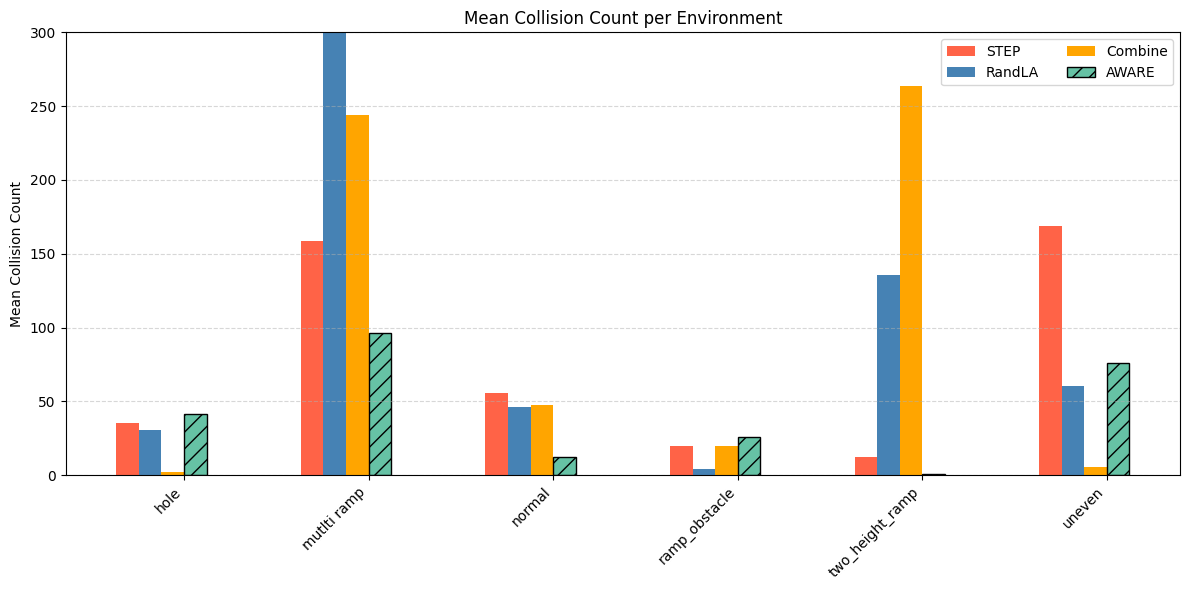

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# Map from (rounded_start, rounded_goal) -> label
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "multi ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def relabel_stats(stats):
    new_stats = {}
    for key, values in stats.items():
        # If key is already a string like "hole", keep it
        if isinstance(key, str):
            label = key
        # If key is a (start, goal) tuple, map it through env_map
        elif isinstance(key, tuple) and len(key) == 2:
            start, goal = key
            label = env_map.get((start, goal), f"{start}→{goal}")
        else:
            label = str(key)
        new_stats[label] = values
    return new_stats


# Series: step, randla, combine, full, final-full, NEW(6)
stats1_labeled = relabel_stats(stats1)  # Step
stats2_labeled = relabel_stats(stats2)  # RandLA
stats3_labeled = relabel_stats(stats3)  # Combine
stats4_labeled = relabel_stats(stats4)  # Full map Combine
stats5_labeled = relabel_stats(stats5)  # Final full map Combine
stats6_labeled = relabel_stats(stats6)  # NEW

# Use ALL labels across the 6 series
all_labels = sorted(
    set(stats1_labeled) |
    set(stats2_labeled) |
    set(stats3_labeled) |
    set(stats4_labeled) |
    set(stats5_labeled) |
    set(stats6_labeled)
)

# Build arrays (collision_count means)
step_collision_means    = [stats1_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
randla_collision_means  = [stats2_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
combine_collision_means = [stats3_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
full_collision_means    = [stats4_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
final_full_means        = [stats5_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
new_collision_means     = [stats6_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]

# --- Spacing + centered offsets (like your success-rate plot with 6 bars) ---
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing

width = 0.22  # slightly narrower to fit 6 bars per group
offsets = [-2.5*width, -1.5*width, -0.5*width, 0.5*width, 1.5*width, 2.5*width]

plt.figure(figsize=(max(12, len(all_labels)*0.8), 6))

bars1 = plt.bar(x + offsets[0], step_collision_means,    width, label='STEP', color='tomato')
bars2 = plt.bar(x + offsets[1], randla_collision_means,  width, label='RandLA', color='steelblue')
bars3 = plt.bar(x + offsets[2], combine_collision_means, width, label='Combine', color='orange')
# bars4 = plt.bar(x + offsets[3], full_collision_means,    width, label='Full map Combine ',         color='purple', edgecolor='black',hatch='//' )
# bars5 = plt.bar(x + offsets[4], final_full_means,        width, label='Partial full map Combine ',   color='orange', edgecolor='black',hatch='//' )
bars6 = plt.bar(
    x + offsets[3],
    new_collision_means,
    width,
    label='AWARE',
    color='#66C2A5',
    edgecolor='black',
    hatch='//'
)

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Collision Count")
plt.title("Mean Collision Count per Environment")
plt.legend(ncol=2)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Fixed y-limit + annotate only bars exceeding that limit
ylim_val = 300
plt.ylim(0, ylim_val)

# def label_only_over_limit(bars, limit, label_y=None):
#     if label_y is None:
#         label_y = limit - (0.05 * limit)  # small padding below the cap
#     for bar in bars:
#         height = bar.get_height()
#         if height > limit:
#             plt.text(
#                 bar.get_x() + bar.get_width() / 2,
#                 label_y,
#                 f'{height:.1f}',
#                 ha='center',
#                 va='center',
#                 fontsize=6,
#                 fontweight='bold',
#                 color='black'
#             )

# for b in (bars1, bars2, bars3, bars6):
#     label_only_over_limit(b, limit=ylim_val)

plt.tight_layout()
plt.show()


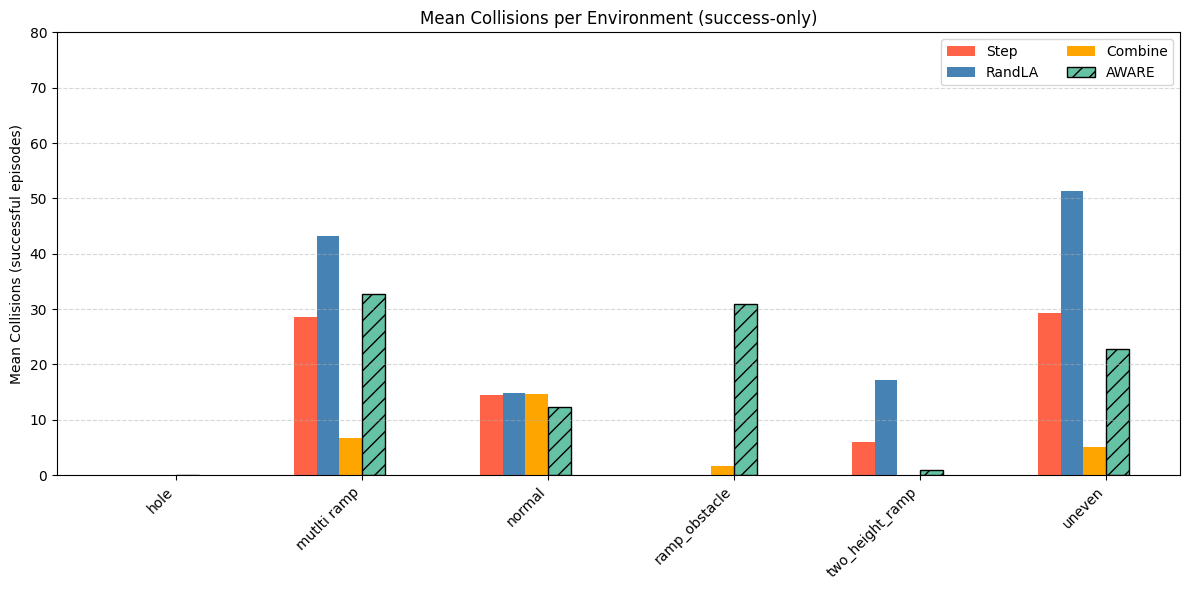

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# Map from (rounded_start, rounded_goal) -> label
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "multi ramp",  # <- match your latest naming
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def relabel_stats(stats):
    new_stats = {}
    for key, values in stats.items():
        # If key is already a string like "hole", keep it
        if isinstance(key, str):
            label = key
        # If key is a (start, goal) tuple, map it through env_map
        elif isinstance(key, tuple) and len(key) == 2:
            start, goal = key
            label = env_map.get((start, goal), f"{start}→{goal}")
        else:
            label = str(key)
        new_stats[label] = values
    return new_stats

# Series: step, randla, combine, full, final-full
stats1_labeled = relabel_stats(stats1)  # Step
stats2_labeled = relabel_stats(stats2)  # RandLA
stats3_labeled = relabel_stats(stats3)  # Combine
stats4_labeled = relabel_stats(stats4)  # Full map Combine
stats5_labeled = relabel_stats(stats5)  # Final full map Combine
stats6_labeled = relabel_stats(stats6)  # NEW
# Use ALL labels across the 5 series
all_labels = sorted(
    set(stats1_labeled) |
    set(stats2_labeled) |
    set(stats3_labeled) |
    set(stats4_labeled) |
    set(stats5_labeled)
)

# Build arrays from mean_collision_success
step_means    = [stats1_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]
randla_means  = [stats2_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]
combine_means = [stats3_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]
full_means    = [stats4_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]
final_means   = [stats5_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]
new_means     = [stats6_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]
# Spacing + centered offsets (5 bars per group)
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing

width = 0.22  # narrow enough to fit 5 bars
offsets = [-2.5*width, -1.5*width, -0.5*width, 0.5*width, 1.5*width, 2.5*width]  # Step, RandLA, Combine, Full, Final Full

plt.figure(figsize=(max(12, len(all_labels)*0.8), 6))

bars1 = plt.bar(x + offsets[0], step_means,    width, label='Step',     color='tomato')
bars2 = plt.bar(x + offsets[1], randla_means,  width, label='RandLA',   color='steelblue')
bars3 = plt.bar(x + offsets[2], combine_means, width, label='Combine',  color='orange')
# bars4 = plt.bar(x + offsets[3], full_means,    width, label='Full map Combine',       color='purple',
#                 edgecolor='black', hatch='//')
# bars5 = plt.bar(x + offsets[4], final_means,   width, label='Partial full map Combine', color='orange',
#                 edgecolor='black', hatch='//')
bars6 = plt.bar(x + offsets[3], new_means,     width, label='AWARE',                    color='#66C2A5',
                edgecolor='black', hatch='//')

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Collisions (successful episodes)")
plt.title("Mean Collisions per Environment (success-only)")
plt.legend(ncol=2)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Fixed y-limit + annotate only bars exceeding that limit
ylim_val = 80
plt.ylim(0, ylim_val)

def label_only_over_limit(bars, limit, label_y=None):
    if label_y is None:
        label_y = limit - (0.05 * limit)  # small padding below the cap
    for bar in bars:
        height = bar.get_height()
        if height > limit:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                label_y,
                f'{height:.1f}',
                ha='center',
                va='center',
                fontsize=6,
                fontweight='bold',
                color='black'
            )

for b in (bars1, bars2, bars3, bars6):
    label_only_over_limit(b, limit=ylim_val)

plt.tight_layout()
plt.show()


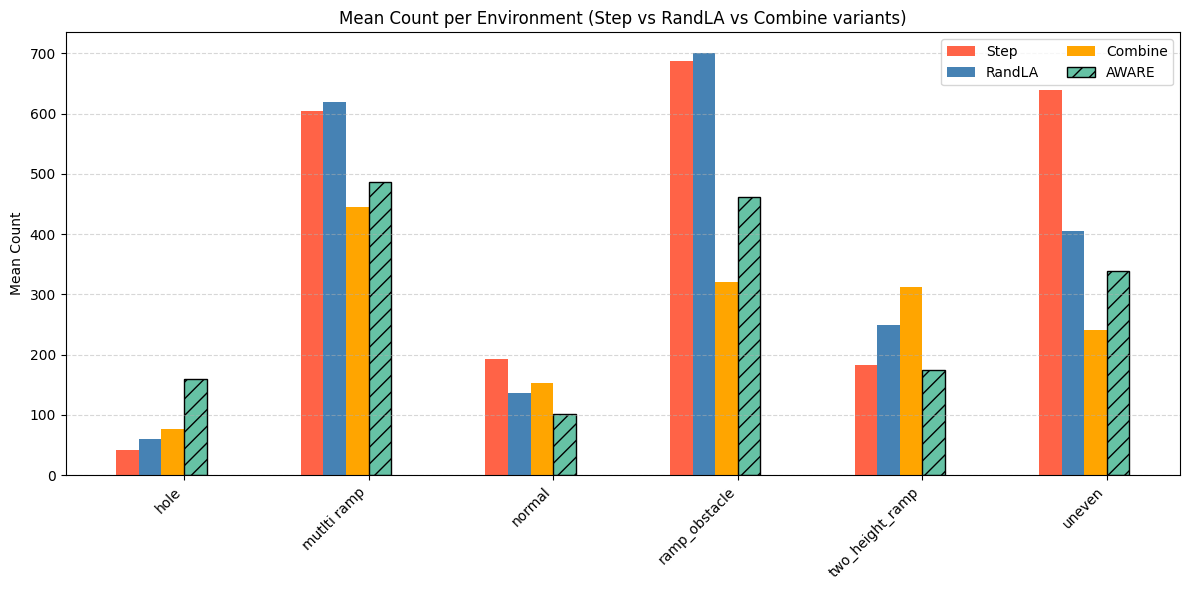

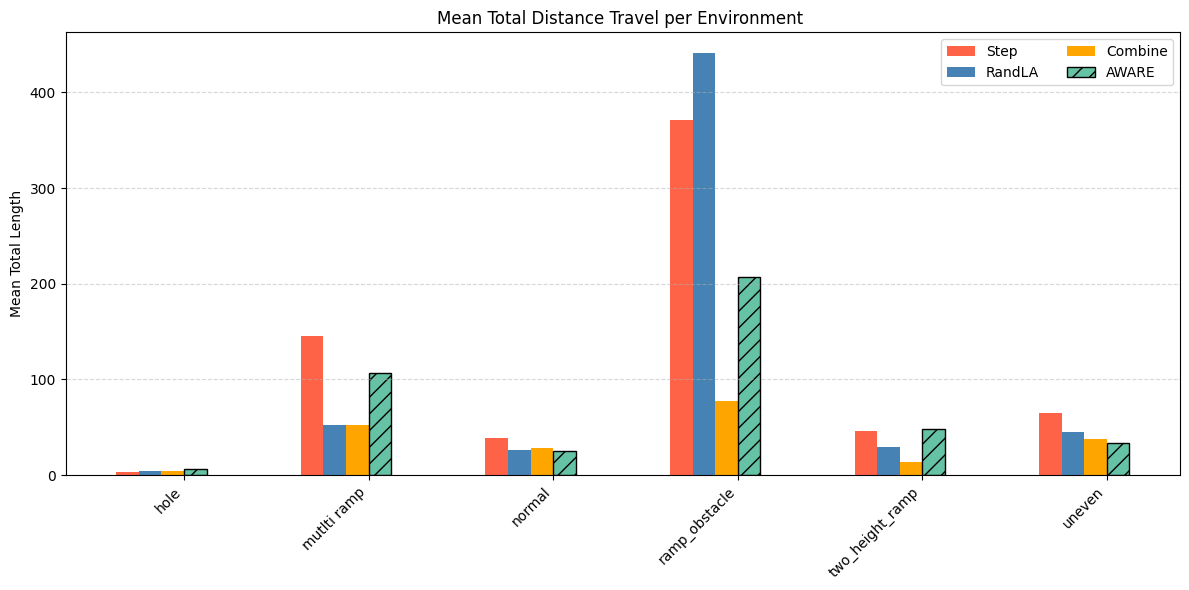

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# Mapping from (rounded start, rounded goal) -> environment label
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "multi ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def relabel_stats(stats):
    new_stats = {}
    for key, values in stats.items():
        # If key is already a string like "hole", keep it
        if isinstance(key, str):
            label = key
        # If key is a (start, goal) tuple, map it through env_map
        elif isinstance(key, tuple) and len(key) == 2:
            start, goal = key
            label = env_map.get((start, goal), f"{start}→{goal}")
        else:
            label = str(key)
        new_stats[label] = values
    return new_stats


# Apply relabeling (5 series here)
stats1_labeled = relabel_stats(stats1)  # Step
stats2_labeled = relabel_stats(stats2)  # RandLA
stats3_labeled = relabel_stats(stats3)  # Combine
stats4_labeled = relabel_stats(stats4)  # Full map Combine
stats5_labeled = relabel_stats(stats5)  # Final full map Combine
stats6_labeled = relabel_stats(stats6)  # NEW
# Use ALL labels across the 5 series
all_labels = sorted(
    set(stats1_labeled) |
    set(stats2_labeled) |
    set(stats3_labeled) |
    set(stats4_labeled) |
    set(stats5_labeled) |
    set(stats6_labeled)
)

# -------------------------------
# Data arrays
# -------------------------------
step_counts    = [stats1_labeled.get(label, {}).get("count", 0) for label in all_labels]
randla_counts  = [stats2_labeled.get(label, {}).get("count", 0) for label in all_labels]
combine_counts = [stats3_labeled.get(label, {}).get("count", 0) for label in all_labels]
full_counts    = [stats4_labeled.get(label, {}).get("count", 0) for label in all_labels]
final_counts   = [stats5_labeled.get(label, {}).get("count", 0) for label in all_labels]
new_counts     = [stats6_labeled.get(label, {}).get("count", 0) for label in all_labels]
step_lengths    = [stats1_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
randla_lengths  = [stats2_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
combine_lengths = [stats3_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
full_lengths    = [stats4_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
final_lengths   = [stats5_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
new_lengths     = [stats6_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
# --- Layout and spacing (centered 5 bars per group) ---
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing
width = 0.22
offsets = [-2.5*width, -1.5*width, -0.5*width, 0.5*width, 1.5*width, 2.5*width]

def label_only_over_limit(bars, limit=None, label_y=None):
    """If bar height > limit, draw the numeric label at label_y."""
    if limit is None or label_y is None:
        return
    for bar in bars:
        h = bar.get_height()
        if h > limit:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                label_y,
                f'{h:.1f}',
                ha='center', va='center',
                fontsize=6, fontweight='bold', color='black'
            )

# -------------------------------
# Plot: Mean Count comparison
# -------------------------------
plt.figure(figsize=(max(12, len(all_labels)*0.8), 6))

b1 = plt.bar(x + offsets[0], step_counts,    width, label='Step',                   color='tomato')
b2 = plt.bar(x + offsets[1], randla_counts,  width, label='RandLA',                 color='steelblue')
b3 = plt.bar(x + offsets[2], combine_counts, width, label='Combine',                color='orange')
# b4 = plt.bar(x + offsets[3], full_counts,    width, label='Full map Combine',       color='purple',
#              edgecolor='black', hatch='//')
# b5 = plt.bar(x + offsets[4], final_counts,   width, label='Final full map Combine', color='orange',
#              edgecolor='black', hatch='//')
b6 = plt.bar(x + offsets[3], new_counts,     width, label='AWARE',                    color='#66C2A5',
             edgecolor='black', hatch='//')
plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Count")
plt.title("Mean Count per Environment (Step vs RandLA vs Combine variants)")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(ncol=2)

# Optional fixed y-limit + capping labels
# ylim_val = 80
# plt.ylim(0, ylim_val)
# for bars in (b1, b2, b3, b4, b5):
#     label_only_over_limit(bars, limit=ylim_val, label_y=0.95*ylim_val)

plt.tight_layout()
plt.show()

# -------------------------------
# Plot: Mean Total Length comparison
# -------------------------------
plt.figure(figsize=(max(12, len(all_labels)*0.8), 6))

b1 = plt.bar(x + offsets[0], step_lengths,    width, label='Step',                   color='tomato')
b2 = plt.bar(x + offsets[1], randla_lengths,  width, label='RandLA',                 color='steelblue')
b3 = plt.bar(x + offsets[2], combine_lengths, width, label='Combine',                color='orange')
# b4 = plt.bar(x + offsets[3], full_lengths,    width, label='Full map Combine',       color='purple',
#              edgecolor='black', hatch='//')
# b5 = plt.bar(x + offsets[4], final_lengths,   width, label='Final full map Combine', color='orange',
#              edgecolor='black', hatch='//')
b6 = plt.bar(x + offsets[3], new_lengths,     width, label='AWARE',                    color='#66C2A5',
             edgecolor='black', hatch='//')
plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Total Length")
plt.title("Mean Total Distance Travel per Environment ")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(ncol=2)

# Optional fixed y-limit + capping labels
# ylim_val = 400
# plt.ylim(0, ylim_val)
# for bars in (b1, b2, b3, b4, b5):
#     label_only_over_limit(bars, limit=ylim_val, label_y=0.95*ylim_val)

plt.tight_layout()
plt.show()


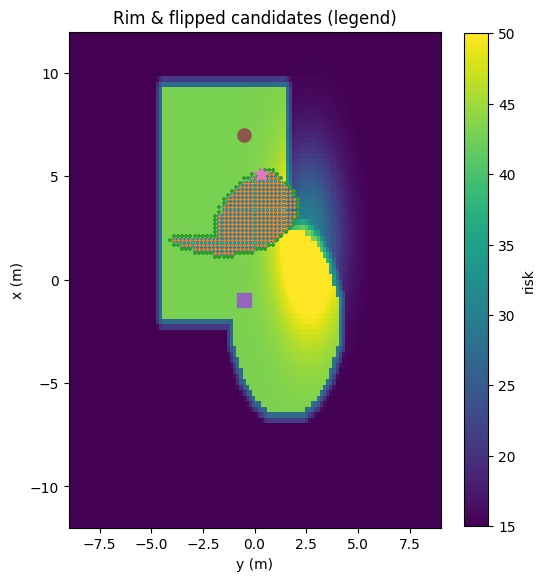

('/mnt/data/rim_debug_legend.png', {'chosen_ij': None, 'num_candidates': 0})

In [93]:
# Re-run the rim visualization with legend (after reset)
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label as _label, binary_dilation as _bd, generate_binary_structure as _gbs, distance_transform_edt as _dt
from scipy.ndimage import distance_transform_edt as edt

def compute_and_visualize_rim_debug_with_legend(
    risk_grid, x_edges, y_edges,
    vehicle_xy, destination_point, gi, gj, MAX,
    save_path=None
):
    safe_thr = 0.95 * MAX
    struct = _gbs(2, 1)
    high_mask = np.isfinite(risk_grid) & (risk_grid >= safe_thr)

    if not high_mask[gi, gj]:
        hi, hj = np.nonzero(high_mask)
        if hi.size > 0:
            Xc = (x_edges[:-1] + x_edges[1:]) * 0.5
            Yc = (y_edges[:-1] + y_edges[1:]) * 0.5
            centers = np.column_stack((Xc[hi], Yc[hj]))
            gxy = np.asarray(destination_point, dtype=float)
            best = np.argmin(np.linalg.norm(centers - gxy, axis=1))
            gi, gj = int(hi[best]), int(hj[best])

    labeled, ncc = _label(high_mask, structure=struct)
    comp_id = labeled[gi, gj] if ncc > 0 and labeled[gi, gj] != 0 else 0

    if comp_id != 0:
        comp_mask = (labeled == comp_id)
    else:
        comp_mask = np.zeros_like(high_mask, dtype=bool)
        comp_mask[gi, gj] = True

    rim = _bd(comp_mask, structure=struct) & (~comp_mask)

    gxy = np.asarray(destination_point, dtype=float)
    vxy = np.asarray(vehicle_xy, dtype=float)
    g_to_v = vxy - gxy
    g_to_v /= (np.linalg.norm(g_to_v) + 1e-9)

    Xc = (x_edges[:-1] + x_edges[1:]) * 0.5
    Yc = (y_edges[:-1] + y_edges[1:]) * 0.5
    ii, jj = np.indices(risk_grid.shape)
    centers = np.column_stack((Xc[ii.ravel()], Yc[jj.ravel()]))
    dirs = centers - gxy
    dirs /= (np.linalg.norm(dirs, axis=1, keepdims=True) + 1e-9)
    dots = (dirs @ g_to_v).reshape(risk_grid.shape)
    flipped_mask = (dots <= 0.0)

    cand_mask = rim & np.isfinite(risk_grid) & (risk_grid < safe_thr) & flipped_mask
    cand_cells = np.argwhere(cand_mask)
    if cand_cells.size == 0:
        rim2 = _bd(rim, structure=struct) & (~comp_mask)
        cand_mask = rim2 & np.isfinite(risk_grid) & (risk_grid < safe_thr) & flipped_mask
        cand_cells = np.argwhere(cand_mask)

    chosen_ij = None
    if cand_cells.size > 0:
        dist_from_blob = _dt(~comp_mask)
        scores = dist_from_blob[cand_cells[:, 0], cand_cells[:, 1]]
        risks = risk_grid[cand_cells[:, 0], cand_cells[:, 1]]
        order = np.lexsort((risks, -scores))
        best = cand_cells[order[0]]
        chosen_ij = (int(best[0]), int(best[1]))

    fig, ax = plt.subplots(figsize=(6,8))
    extent = [y_edges[0], y_edges[-1], x_edges[0], x_edges[-1]]
    im = ax.imshow(np.flipud(risk_grid.T), extent=extent, origin="lower", aspect="equal")
    fig.colorbar(im, ax=ax, shrink=0.8, label="risk")

    hi, hj = np.nonzero(high_mask)
    ax.scatter(Yc[hj], Xc[hi], s=8, marker='x', label='High-risk (≥0.95·MAX)')
    ci, cj = np.nonzero(comp_mask)
    ax.scatter(Yc[cj], Xc[ci], s=6, marker='.', label='Blocking component')
    ri, rj = np.nonzero(rim)
    ax.scatter(Yc[rj], Xc[ri], s=8, marker='+', label='1-cell rim')
    fi, fj = np.nonzero(cand_mask)
    # TOP  
    ax.scatter(Yc[fj], Xc[fi], s=34, marker='+', alpha=0.8, label='Candidates (safe & flipped)')
    if chosen_ij is not None:
        ax.scatter([Yc[chosen_ij[1]]], [Xc[chosen_ij[0]]], marker='^', s=120, label='Chosen candidate')
    ax.scatter([vehicle_xy[1]], [vehicle_xy[0]], marker='s', s=90, label='Vehicle')
    ax.scatter([destination_point[1]], [destination_point[0]], marker='o', s=90, label='Final goal')
    ax.scatter([Yc[gj]], [Xc[gi]], marker='*', s=120, label='Start (gi,gj)')

    # ax.legend(loc='upper right', fontsize=8)
    ax.set_title("Rim & flipped candidates (legend)")
    ax.set_xlabel("y (m)")
    ax.set_ylabel("x (m)")

    # if save_path:
    #     fig.savefig(save_path, bbox_inches="tight", dpi=140)
    plt.show()

    return {"chosen_ij": chosen_ij, "num_candidates": int(cand_cells.shape[0])}

# --- Synthetic map ---
Nx, Ny = 120, 90
x_edges = np.linspace(-12, 12, Nx+1)
y_edges = np.linspace(-9, 9, Ny+1)
Xc = (x_edges[:-1] + x_edges[1:]) * 0.5
Yc = (y_edges[:-1] + y_edges[1:]) * 0.5
X, Y = np.meshgrid(Xc, Yc, indexing="ij")

MAX = 50.0
risk = 15.0 * np.ones_like(X)
rect = (X > -6.0) & (X < 2.0) & (Y > -7.0) & (Y < 1.5)
cap = (((X-2.0)**2 + (Y-1.5)**2) < (3.4**2)) & (Y >= 1.5-3.4)
obstacle = rect | cap
dist_out = edt(~obstacle)
risk += 6.0*np.clip(3.0 - dist_out, 0, None)
risk += 10.0*np.clip(1.0 - dist_out, 0, None)
risk += 16.0*np.exp(-((X-3.5)**2/(2*1.4**2) + (Y+1.5)**2/(2*2.2**2)))
risk = np.clip(risk, 0, MAX)

vehicle_xy = (-1.0, -0.5)
destination_point = (7.0, -0.5)
gi = np.searchsorted(Xc, 6.0); gi = int(np.clip(gi, 0, Nx-1))
gj = np.searchsorted(Yc, -0.5); gj = int(np.clip(gj, 0, Ny-1))

out_path = "/mnt/data/rim_debug_legend.png"
res = compute_and_visualize_rim_debug_with_legend(
    risk_grid=risk, x_edges=x_edges, y_edges=y_edges,
    vehicle_xy=vehicle_xy, destination_point=destination_point,
    gi=gi, gj=gj, MAX=MAX, save_path=out_path
)
out_path, res
